# Define your own problem

Apart from giving you access to already implemented problems, QLauncher allows you to easily define your own problems.

To define a new problem and add it to QLauncher you need to create a subclass of class problem implementing the formulation in at least one of the formats used by quantum computers such as QUBO, Hamiltonian or BQM. Here's the example definition of Vertex Cover problem:

In [ ]:
from typing import Literal

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from pyqubo import Array, Binary

from qlauncher.base import Problem
from qlauncher.base.models import QUBO


class VertexCover(Problem):
	"""
	Class for the Vertex Cover problem which is a combinatorial problem involving choosing a subset of graph vertices such that each edge of the graph has at least one vertex in the chosen subset.

	Attributes:
		instance (nx.Graph): The graph for which the coloring problem is to be solved.


	"""

	def __init__(self, instance: nx.Graph, instance_name: str = 'unnamed') -> None:
		"""
		Args:
			instance (nx.Graph): Graph representing the TSP instance.
			instance_name (str): Name of the instance.
		"""
		super().__init__(instance=instance, instance_name=instance_name)

	# method to visualize a problem and optionally a solution to it
	def visualize(self, solution: list[int] | None = None) -> None:
		pos = nx.spring_layout(self.instance)
		plt.figure(figsize=(8, 6))
		if solution is not None:
			solution_colors = ['red' if x else 'skyblue' for x in solution]
			nx.draw_networkx_nodes(self.instance, pos, node_size=500, node_color=solution_colors)
		else:
			nx.draw_networkx_nodes(self.instance, pos, node_size=500, node_color='skyblue')
		nx.draw_networkx_edges(self.instance, pos, edge_color='gray')
		nx.draw_networkx_labels(self.instance, pos, font_size=10, font_weight='bold')
		plt.title('Vertex Cover Problem Instance Visualization')
		plt.show()

	# method to load a predefined toy example
	@staticmethod
	def from_preset(instance_name: Literal['default'], **kwargs) -> 'VertexCover':
		match instance_name:
			case 'default':
				node_list = list(range(5))
				edge_list = [(0, 1), (0, 2), (1, 3), (2, 3), (2, 4), (3, 4)]
		graph = nx.Graph()
		graph.add_nodes_from(node_list)
		graph.add_edges_from(edge_list)
		return VertexCover(graph, instance_name=instance_name)

	# method which generates ransom problem instance
	@staticmethod
	def generate_vertex_cover_instance(num_vertices: int, edge_probability: int) -> 'VertexCover':
		graph = nx.gnp_random_graph(num_vertices, edge_probability)
		return VertexCover(graph)

	def to_qubo(self, constraint_weight: int = 5, cost_weight: int = 1) -> QUBO:
		vertices = self.instance.nodes()
		edges = self.instance.edges()
		x = Array.create('x', shape=(len(vertices),), vartype='BINARY')

		# penalty for number of vertices used
		qubo: Binary = sum(cost_weight * x[v] for v in vertices)

		# penalty for violating constraint, not covering all edges
		for e in edges:
			qubo += constraint_weight * (1 - x[e[0]] - x[e[1]] + x[e[0]] * x[e[1]])

		qubo_dict, offset = qubo.compile().to_qubo()

		# turn qubo dict into qubo matrix
		Q_matrix = np.zeros((len(vertices), len(vertices)))
		var_labels = [f'x[{k}]' for k in range(len(vertices))]
		for i, vi in enumerate(var_labels):
			for j, vj in enumerate(var_labels):
				key = (vi, vj)
				if key in qubo_dict:
					Q_matrix[i, j] = qubo_dict[key]
		return QUBO(Q_matrix, offset)


There is a couple of things going on in here. The Vertex Cover class has two methods. The first one `visualize` is a completely optional helper function which can be used to draw a graph, Here we use it to see the graph matching the provided edge list.

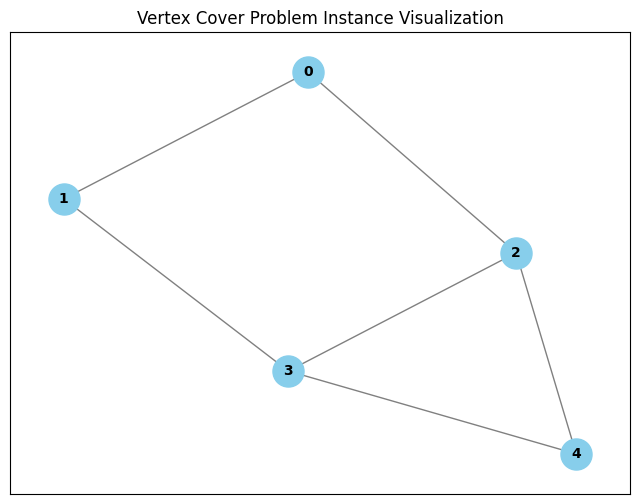

In [2]:
graph = nx.from_edgelist([(0, 1), (0, 2), (1, 3), (2, 3), (2, 4), (3, 4)])
pr = VertexCover(graph)
pr.visualize()

The second method `to_qubo` is a problem formulation, for problem to be solved by QLauncher it needs to implement at least one method of this type, which include `to_qubo`, `to_hamiltonian` and `to_bqm` returning the object of the corresponding `ProblemLike` class (`QUBO`, `Hamiltonian`, `BQM`).

### Qubits and Penalty Function

To create a proper problem formulation you need to do two things:

1. Find a way to express a solution (any solution, not just the optimal one) as a set of binary variables, those binary variables will be mapped to qubits by a quantum computer.
2. Construct a penalty function which acts on the qubit representation and based on the values of qubits assigns a "penalty" to it, for the quantum algorithm to work properly the penalty function should assign higher values to invalid or suboptimal solutions and lower values, possibly 0, to an optimal solution.

The penalty function needs to follow a given format, e.g. a QUBO formulation needs to be a polynomial of at most second order expressed as a QUBO matrix and offset where $i'th$, $j'th$ matrix entry corresponds to the coefficient of $x_{i}x_{j}$ term in the function and offset corresponds to the constant. On the other hand the Hamiltonian formulation can be of higher order and needs to be represented by a SparsePauliOp from the qiskit library.

Now that you have defined a problem and completed its formulation, you can pass an instance of the problem to QLauncher which will automatically find the formulation.

In [3]:
from qlauncher.launcher import QLauncher
from qlauncher.routines.qiskit import QAOA, QiskitBackend

solution = QLauncher(pr, QAOA(p=5), QiskitBackend('local_simulator')).run()
solution

Result(bitstring=10011, energy=3.0)

We can once again use the problem's visualize method, this time to check the solution's correctness, unfortunately due to algorithm's indeterminism we cannot guarantee the correct solution each time

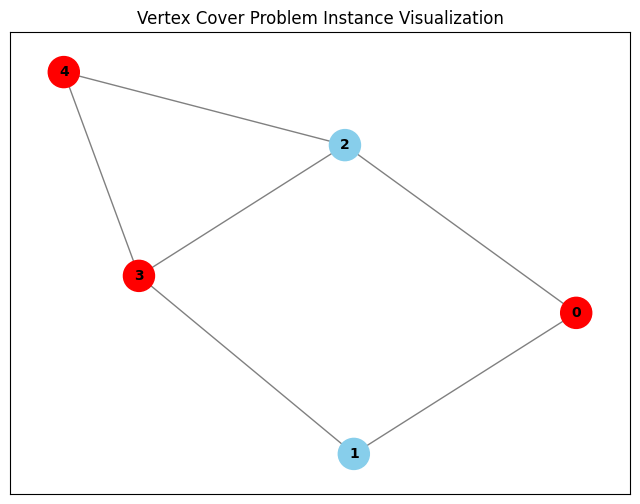

In [4]:
pr.visualize([int(x) for x in solution.best_bitstring])

A nice convenience introduced by QLauncher is the fact that you only need to define the formulation in a single format, QLauncher handles the conversion between different formats under the hood. Since QAOA requires the problem to be formulated as a Hamiltonian and we provided a QUBO formulation, QLauncher will convert the `QUBO` object returned by from our problem's `to_qubo()` method into a  a `Hamiltonian`. """